# House Price Prediction — Linear Regression

**Goal:** Predict house price from features like area, location, rooms, and age.

**Data:** 2,000 houses with `Area`, `Bedrooms`, `Bathrooms`, `Floors`, `YearBuilt`, `Location`, `Condition`, `Garage`, `Price`.


## 1. Setup & Imports

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

DATA_PATH = 'House Price Prediction Dataset.csv'


## 2. Load the Data

In [12]:
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()


Shape: (2000, 10)


,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [13]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB


## 3. Exploratory Data Analysis (EDA)

### 3.1 Null check

In [14]:
null_summary = pd.DataFrame({
    'null_count': df.isnull().sum(),
    'null_pct': (df.isnull().sum() / len(df) * 100).round(2),
    'dtype': df.dtypes.astype(str),
})
null_summary


,null_count,null_pct,dtype
Id,0,0.0,int64
Area,0,0.0,int64
Bedrooms,0,0.0,int64
Bathrooms,0,0.0,int64
Floors,0,0.0,int64
YearBuilt,0,0.0,int64
Location,0,0.0,object
Condition,0,0.0,object
Garage,0,0.0,object
Price,0,0.0,int64


**Finding:** No missing values. We still add imputation logic later, just in case.


### 3.2 Duplicate check

In [15]:
print(f"Fully duplicated rows: {df.duplicated().sum()}")
print(f"Duplicated Id values: {df['Id'].duplicated().sum()}")


Fully duplicated rows: 0
Duplicated Id values: 0


### 3.3 Descriptive statistics

In [16]:
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Id,2000.0,NaN,NaN,NaN,1000.5,577.494589,1.0,500.75,1000.5,1500.25,2000.0
Area,2000.0,NaN,NaN,NaN,2786.2095,1295.146799,501.0,1653.0,2833.0,3887.5,4999.0
Bedrooms,2000.0,NaN,NaN,NaN,3.0035,1.424606,1.0,2.0,3.0,4.0,5.0
Bathrooms,2000.0,NaN,NaN,NaN,2.5525,1.10899,1.0,2.0,3.0,4.0,4.0
Floors,2000.0,NaN,NaN,NaN,1.9935,0.809188,1.0,1.0,2.0,3.0,3.0
YearBuilt,2000.0,NaN,NaN,NaN,1961.446,35.926695,1900.0,1930.0,1961.0,1993.0,2023.0
Location,2000,4,Downtown,558,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Condition,2000,4,Fair,521,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Garage,2000,2,No,1038,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Price,2000.0,NaN,NaN,NaN,537676.855,276428.845719,50005.0,300098.0,539254.0,780086.0,999656.0


In [17]:
for col in ['Location', 'Condition', 'Garage']:
    print(f"--- {col} ---")
    print(df[col].value_counts())
    print()


--- Location ---
Location
Downtown    558
Urban       485
Suburban    483
Rural       474
Name: count, dtype: int64

--- Condition ---
Condition
Fair         521
Excellent    511
Poor         507
Good         461
Name: count, dtype: int64

--- Garage ---
Garage
No     1038
Yes     962
Name: count, dtype: int64



### 3.4 Distribution of the target variable (`Price`)

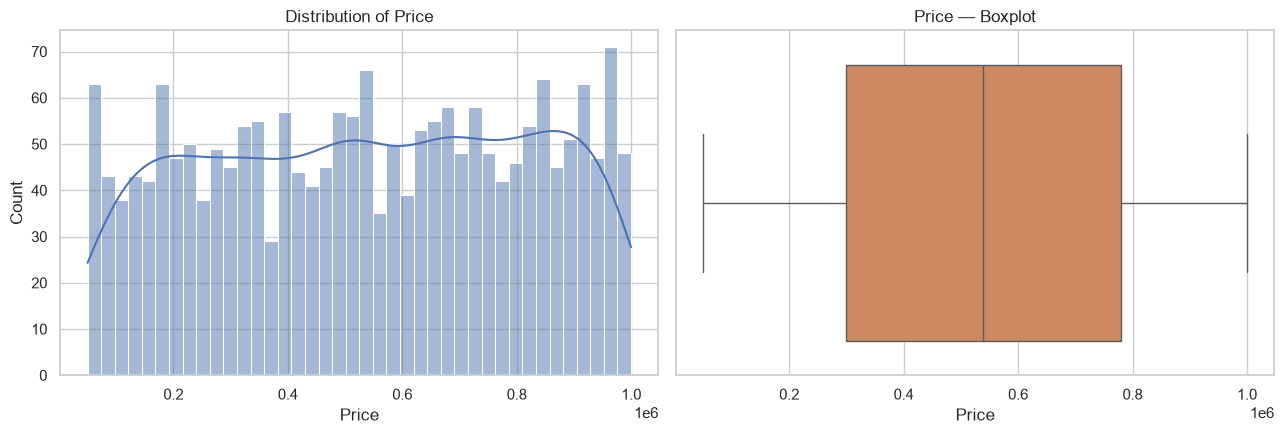

Skewness: -0.064
Kurtosis: -1.203


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(df['Price'], kde=True, bins=40, ax=axes[0], color='#4C72B0')
axes[0].set_title('Distribution of Price')
axes[0].set_xlabel('Price')

sns.boxplot(x=df['Price'], ax=axes[1], color='#DD8452')
axes[1].set_title('Price — Boxplot')

plt.tight_layout()
plt.show()

print(f"Skewness: {df['Price'].skew():.3f}")
print(f"Kurtosis: {df['Price'].kurt():.3f}")


**Observation:** `Price` is fairly symmetric, no long tail → no need to log-transform it.


### 3.5 Distributions of the numeric predictors

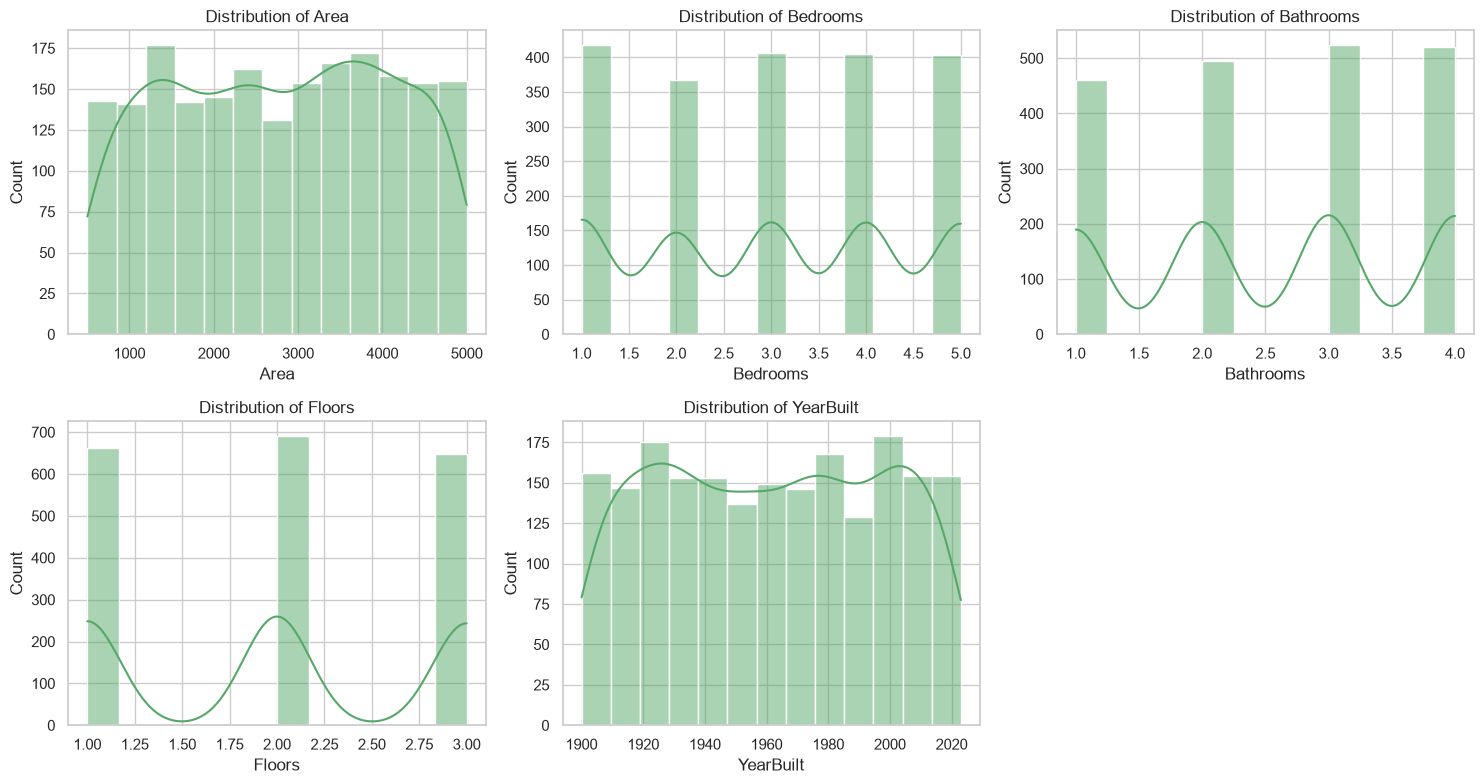

In [19]:
numeric_cols = ['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for ax, col in zip(axes, numeric_cols):
    sns.histplot(df[col], kde=True, ax=ax, color='#55A868')
    ax.set_title(f'Distribution of {col}')
axes[-1].axis('off')
plt.tight_layout()
plt.show()


### 3.6 Categorical predictors vs. Price

C:\Users\sudar\AppData\Local\Temp\ipykernel_23804\2279792183.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y='Price', ax=ax, palette='pastel')
C:\Users\sudar\AppData\Local\Temp\ipykernel_23804\2279792183.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y='Price', ax=ax, palette='pastel')
C:\Users\sudar\AppData\Local\Temp\ipykernel_23804\2279792183.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y='Price', ax=ax, palette='pastel')


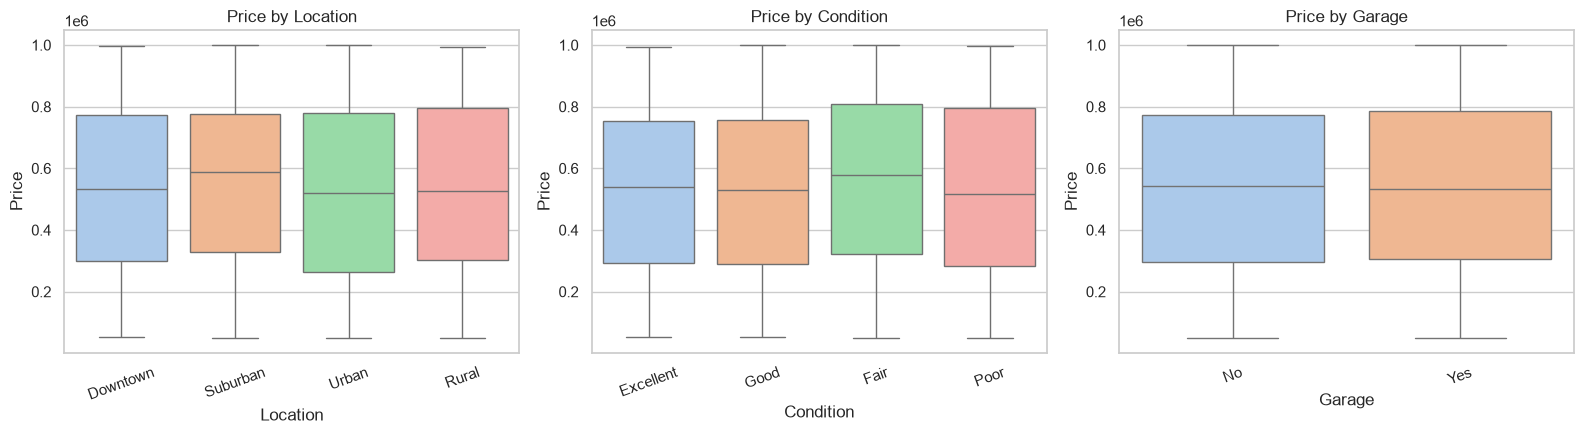

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, col in zip(axes, ['Location', 'Condition', 'Garage']):
    sns.boxplot(data=df, x=col, y='Price', ax=ax, palette='pastel')
    ax.set_title(f'Price by {col}')
    ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()


**Observation:** Price looks similar across all categories of `Location`, `Condition`, `Garage` — these may not matter much.


## 4. Feature Selection Discussion

Quick expectations before modeling (based on domain knowledge):

| Feature | Expected effect |
|---|---|
| `Area` | Strong ↑ (bigger = pricier) |
| `Bedrooms` / `Bathrooms` | ↑ (more space/comfort) |
| `Floors` | Mixed |
| `Age` | ↓ usually (newer = pricier) |
| `Location` | Strong effect |
| `Condition` | ↑ (better = pricier) |
| `Garage` | Small ↑ |
| `Id` | None — excluded |

We'll keep all features and let the data confirm or reject these guesses.


## 5. Missing Values & Feature Engineering

No missing values (Section 3.1), but we add a safety net anyway:
- **Numeric columns:** fill with median
- **Categorical columns:** fill with mode


In [21]:
df_clean = df.copy()

numeric_fill_cols = ['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt']
categorical_fill_cols = ['Location', 'Condition', 'Garage']

for col in numeric_fill_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

for col in categorical_fill_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

print("Nulls remaining:", df_clean.isnull().sum().sum())


Nulls remaining: 0


### 5.2 Feature Engineering: `Age`

Convert `YearBuilt` → `Age` (as of 2026), then drop `YearBuilt` and `Id`.


In [22]:
REFERENCE_YEAR = 2026

df_clean['Age'] = REFERENCE_YEAR - df_clean['YearBuilt']
df_clean = df_clean.drop(columns=['Id', 'YearBuilt'])

df_clean[['Age']].describe()


,Age
count,2000.000000
mean,64.554000
std,35.926695
min,3.000000
25%,33.000000
50%,65.000000
75%,96.000000
max,126.000000


### 5.3 One-Hot Encoding

Encode `Location`, `Condition`, `Garage` with `drop_first=True` to avoid the dummy variable trap.


In [23]:
categorical_cols = ['Location', 'Condition', 'Garage']

df_encoded = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)

print("Shape after encoding:", df_encoded.shape)
df_encoded.head()


Shape after encoding: (2000, 13)


,Area,Bedrooms,Bathrooms,Floors,Price,Age,Location_Rural,Location_Suburban,Location_Urban,Condition_Fair,Condition_Good,Condition_Poor,Garage_Yes
0,1360,5,4,3,149919,56,False,False,False,False,False,False,False
1,4272,5,4,3,424998,68,False,False,False,False,False,False,False
2,3592,2,2,3,266746,88,False,False,False,False,True,False,False
3,966,4,2,2,244020,124,False,True,False,True,False,False,True
4,4926,1,4,2,636056,51,False,False,False,True,False,False,True


## 6. Correlation Heatmap

Check which features correlate most with `Price`.


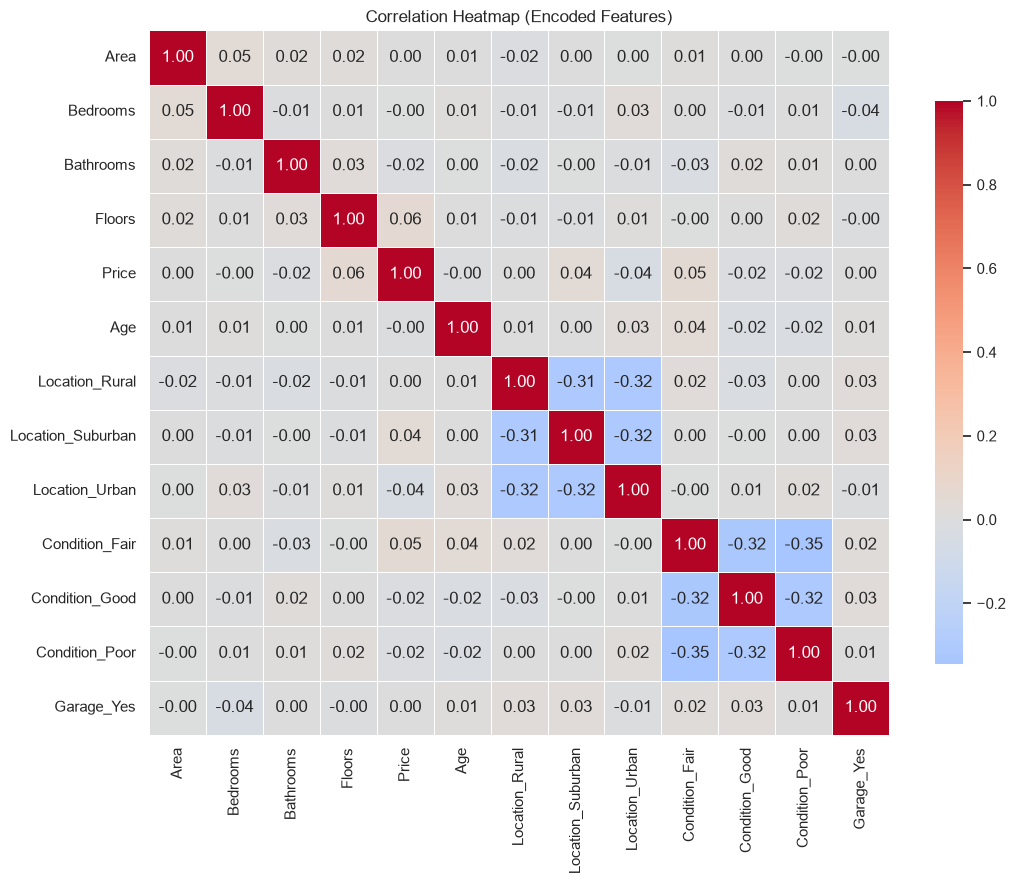

In [24]:
plt.figure(figsize=(11, 9))
corr = df_encoded.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap (Encoded Features)')
plt.tight_layout()
plt.show()


In [25]:
price_corr = corr['Price'].drop('Price').sort_values(key=lambda s: s.abs(), ascending=False)
print("Features ranked by |correlation| with Price:")
price_corr


Features ranked by |correlation| with Price:


Floors               0.055890
Condition_Fair       0.049218
Location_Suburban    0.040303
Location_Urban      -0.038312
Condition_Poor      -0.018437
Condition_Good      -0.017179
Bathrooms           -0.015737
Age                 -0.004845
Bedrooms            -0.003471
Garage_Yes           0.002842
Location_Rural       0.001890
Area                 0.001542
Name: Price, dtype: float64

**Finding:** Every feature has ~zero correlation with `Price` (all under 0.06). This contradicts our expectations from Section 4.

Two likely reasons:
1. `Price` may be synthetically generated, unrelated to other columns.
2. The real relationship could be non-linear (which correlation won't catch).

We'll still build the model as planned, but expect weak performance.


## 7. Train/Test Split (80/20)

In [26]:
X = df_encoded.drop(columns='Price')
y = df_encoded['Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

print(f"Train set: {X_train.shape[0]} rows")
print(f"Test set:  {X_test.shape[0]} rows")
print(f"Features used ({X.shape[1]}): {list(X.columns)}")


Train set: 1600 rows
Test set:  400 rows
Features used (12): ['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'Age', 'Location_Rural', 'Location_Suburban', 'Location_Urban', 'Condition_Fair', 'Condition_Good', 'Condition_Poor', 'Garage_Yes']


## 8. Train a Linear Regression Model

In [27]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

y_pred = lin_reg.predict(X_test)

print("Model trained.")
print(f"Intercept: {lin_reg.intercept_:,.2f}")


Model trained.
Intercept: 516,806.26


## 9. Model Evaluation — MSE, RMSE, R²

In [28]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE):      {mse:,.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:,.2f}")
print(f"R² score:                       {r2:.4f}")


Mean Squared Error (MSE):      78,321,466,146.03
Root Mean Squared Error (RMSE): 279,859.73
R² score:                       -0.0067


In [29]:
baseline_pred = np.full_like(y_test, fill_value=y_train.mean(), dtype=float)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))

print(f"'Always predict the training mean' baseline RMSE: {baseline_rmse:,.2f}")
print(f"Linear Regression model RMSE:                     {rmse:,.2f}")


'Always predict the training mean' baseline RMSE: 279,024.31
Linear Regression model RMSE:                     279,859.73


**Interpretation:** R² is near zero — the model explains almost no variance in `Price`, performing about as well as just guessing the average price. This matches the near-zero correlations from Section 6.


## 10. Actual vs. Predicted Prices

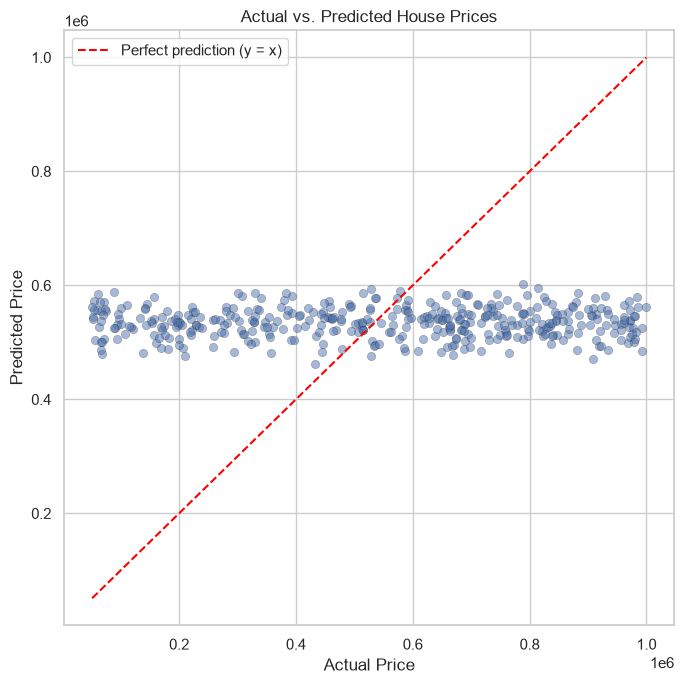

In [30]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.5, color='#4C72B0', edgecolor='k', linewidth=0.3)

lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, color='red', linestyle='--', label='Perfect prediction (y = x)')

plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs. Predicted House Prices')
plt.legend()
plt.tight_layout()
plt.show()


**Reading the plot:** Predictions cluster in a flat band near the average price instead of following the diagonal — visual proof of the near-zero R².


## 11. Residual Plot

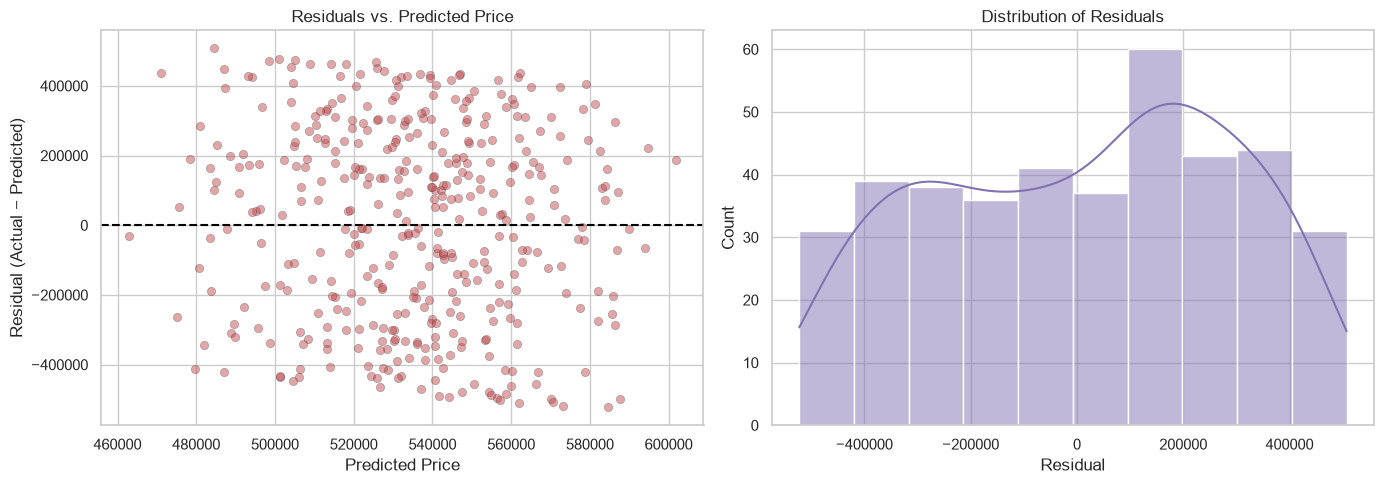

In [31]:
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_pred, residuals, alpha=0.5, color='#C44E52', edgecolor='k', linewidth=0.3)
axes[0].axhline(0, color='black', linestyle='--')
axes[0].set_xlabel('Predicted Price')
axes[0].set_ylabel('Residual (Actual − Predicted)')
axes[0].set_title('Residuals vs. Predicted Price')

sns.histplot(residuals, kde=True, ax=axes[1], color='#8172B2')
axes[1].set_title('Distribution of Residuals')
axes[1].set_xlabel('Residual')

plt.tight_layout()
plt.show()


**Reading the plot:** Residuals are randomly scattered around zero with no pattern — so the model isn't mis-specified, the signal is just genuinely weak.


## 12. Coefficient Analysis

Two views of the coefficients:
1. **Raw** — original units, but not comparable across features.
2. **Standardized** — comparable "impact per 1 std-dev change."


In [32]:
coef_df = pd.DataFrame({
    'feature': X.columns,
    'raw_coefficient': lin_reg.coef_,
}).sort_values('raw_coefficient', key=lambda s: s.abs(), ascending=False)

coef_df


,feature,raw_coefficient
8,Condition_Fair,24083.307846
3,Floors,23727.983633
9,Condition_Good,-12941.044835
7,Location_Urban,-12718.918912
6,Location_Suburban,11511.989815
2,Bathrooms,-9662.248234
10,Condition_Poor,4073.268930
11,Garage_Yes,2373.530579
5,Location_Rural,1317.542020
4,Age,-117.613885


In [33]:
# Standardised coefficients for fair magnitude comparison
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns, index=X_test.index)

lin_reg_scaled = LinearRegression()
lin_reg_scaled.fit(X_train_scaled, y_train)

coef_std_df = pd.DataFrame({
    'feature': X.columns,
    'standardized_coefficient': lin_reg_scaled.coef_,
}).sort_values('standardized_coefficient', key=lambda s: s.abs(), ascending=False)

coef_std_df


,feature,standardized_coefficient
3,Floors,19148.405610
2,Bathrooms,-10714.207403
8,Condition_Fair,10620.734920
7,Location_Urban,-5484.313686
9,Condition_Good,-5440.814630
6,Location_Suburban,4858.400472
4,Age,-4222.684673
10,Condition_Poor,1778.232367
11,Garage_Yes,1185.205708
0,Area,-748.906099


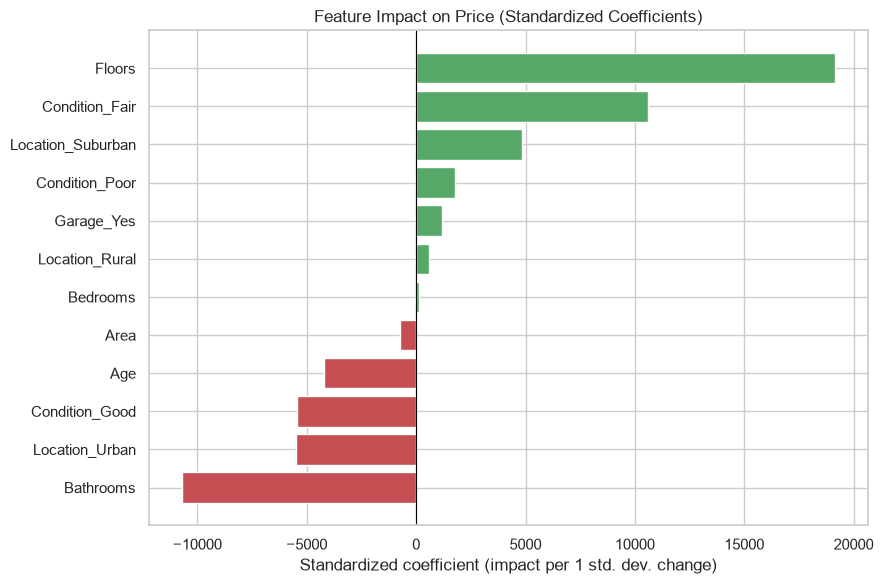

In [34]:
plt.figure(figsize=(9, 6))
plot_df = coef_std_df.sort_values('standardized_coefficient')
colors = ['#C44E52' if v < 0 else '#55A868' for v in plot_df['standardized_coefficient']]
plt.barh(plot_df['feature'], plot_df['standardized_coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Standardized coefficient (impact per 1 std. dev. change)')
plt.title('Feature Impact on Price (Standardized Coefficients)')
plt.tight_layout()
plt.show()


**Interpretation:** Even the largest standardized coefficients shift price by only a few hundred–thousand dollars — tiny next to Price's ~$276K std dev. No feature meaningfully drives price here.


## 13. Bonus: Ridge & Lasso Comparison

Compare Linear Regression to Ridge (L2) and Lasso (L1), both on standardized features.


In [35]:
ridge = Ridge(alpha=1.0, random_state=RANDOM_STATE)
ridge.fit(X_train_scaled, y_train)
ridge_pred = ridge.predict(X_test_scaled)

lasso = Lasso(alpha=1.0, random_state=RANDOM_STATE)
lasso.fit(X_train_scaled, y_train)
lasso_pred = lasso.predict(X_test_scaled)

# Also refit plain linear regression on the standardized features for a like-for-like comparison
linreg_scaled_pred = lin_reg_scaled.predict(X_test_scaled)

def eval_model(name, y_true, y_hat):
    return {
        'model': name,
        'MSE': mean_squared_error(y_true, y_hat),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_hat)),
        'R2': r2_score(y_true, y_hat),
    }

comparison = pd.DataFrame([
    eval_model('Linear Regression', y_test, linreg_scaled_pred),
    eval_model('Ridge (alpha=1.0)', y_test, ridge_pred),
    eval_model('Lasso (alpha=1.0)', y_test, lasso_pred),
]).set_index('model')

comparison


,MSE,RMSE,R2
model,,,
Linear Regression,7.832147e+10,279859.725838,-0.006718
Ridge (alpha=1.0),7.832074e+10,279858.422492,-0.006708
Lasso (alpha=1.0),7.832132e+10,279859.471740,-0.006716


**Interpretation:** Ridge and Lasso perform about the same as plain Linear Regression — expected, since regularization can't create signal that isn't there. Lasso may zero out some features, effectively doing feature selection.


In [36]:
lasso_coef_df = pd.DataFrame({
    'feature': X.columns,
    'lasso_coefficient': lasso.coef_,
}).sort_values('lasso_coefficient', key=lambda s: s.abs(), ascending=False)

zeroed_out = lasso_coef_df[lasso_coef_df['lasso_coefficient'] == 0]['feature'].tolist()
print(f"Features Lasso shrank to exactly zero: {zeroed_out if zeroed_out else 'none'}")
lasso_coef_df


Features Lasso shrank to exactly zero: none


,feature,lasso_coefficient
3,Floors,19147.325949
2,Bathrooms,-10713.226603
8,Condition_Fair,10619.353900
7,Location_Urban,-5484.060083
9,Condition_Good,-5440.774438
6,Location_Suburban,4857.168917
4,Age,-4221.682321
10,Condition_Poor,1776.777409
11,Garage_Yes,1184.232541
0,Area,-747.874440


## 14. Conclusion

- Correlation heatmap: ~no linear relationship with `Price`
- Actual vs. predicted: predictions cluster near the mean
- Residuals: random, no pattern — not a modeling bug
- Coefficients: no feature has a meaningful impact
- Ridge/Lasso: no improvement, confirms it's not overfitting

**Bottom line:** `Price` isn't linearly predictable from the available features. Next steps: verify how `Price` was generated, look for missing features (e.g. school district, interest rates), or try non-linear models.
